<a href="https://colab.research.google.com/github/azholl/azholl/blob/main/lab-6/lab-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing and importing libraries

In [1]:
!pip install textnets

In [2]:
import textnets as tn

Fixing the initial seed for the pseudorandom number generator

In [3]:
tn.params

Parameter              Value         
--------------------   --------------
seed                   5632          
autodownload           False         
figsize                (16, 9)       
lang                   en_core_web_sm
progress_bar           True          
resolution_parameter   0.1           
tuning_parameter       0.5

Helps ensure reproducibility

In [4]:
tn.params["seed"] = 42

Preparing corpus by importing data and saving as df and using tn.Corpus(df["Abstract"]) to pull in just the abstract, since that's the column I focused on in the last lab.

In [5]:
import requests
import io

url = "https://raw.githubusercontent.com/azholl/lis5693/main/lab-6/lab-6-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

import pandas as pd

df = pd.read_csv(io.StringIO(text))
df.head()

,Lens ID,Title,Publication Year,Author/s,Abstract,Keywords
0,000-425-845-807-513,Coping with long-COVID stigma: The role of sel...,2025,Maor Shani; Kilian Wübbelt,Long COVID has been associated with stigmatiza...,NaN
1,000-516-474-169-658,Age and chest computed tomography severity sco...,2024,Merve Erkan,"<AbstractText Label=""INTRODUCTION"">About one-t...",chest CT; long-COVID; pneumonia chest CT sever...
2,000-521-509-636-014,To Long COVID and Beyond,2021,David Misselbrook,David Misselbrook ; ; ; ; New diseases don’t c...,NaN
3,000-579-570-485-747,Children with Long Covid: Co-producing a speci...,2021,Michael Fanner; Elaine Maxwell,"<jats:p>Globally, children have been profoundl...",NaN
4,001-093-041-546-993,"Evaluating the associations among asthma, asth...",2025,Chun-Tse Hung; Yu-Chien Hung; Chi-Won Suk; Chu...,"<AbstractText Label=""OBJECTIVE"" NlmCategory=""O...",Asthma; Asthma control; COVID-19; Long COVID; ...


In [6]:
corpus = tn.Corpus(df["Abstract"], lang="en")

In [7]:
corpus

<Corpus with 20 documents using language model 'en_core_web_sm'>

Create network, had to add mini_docs=3 (instead of 1) to drop terms that only appear in 1 document, and remove_weak_edges=True because my clusters were unreadable with how many terms and edges there were.

In [15]:
t = tn.Textnet(corpus.tokenized(), min_docs=3, remove_weak_edges=True)
t

Textnet,Docs: 20,Terms: 144,Edges: 622


There are 144 terms and 622 edges in my dataset after cleaning it up

Visualize and analyze

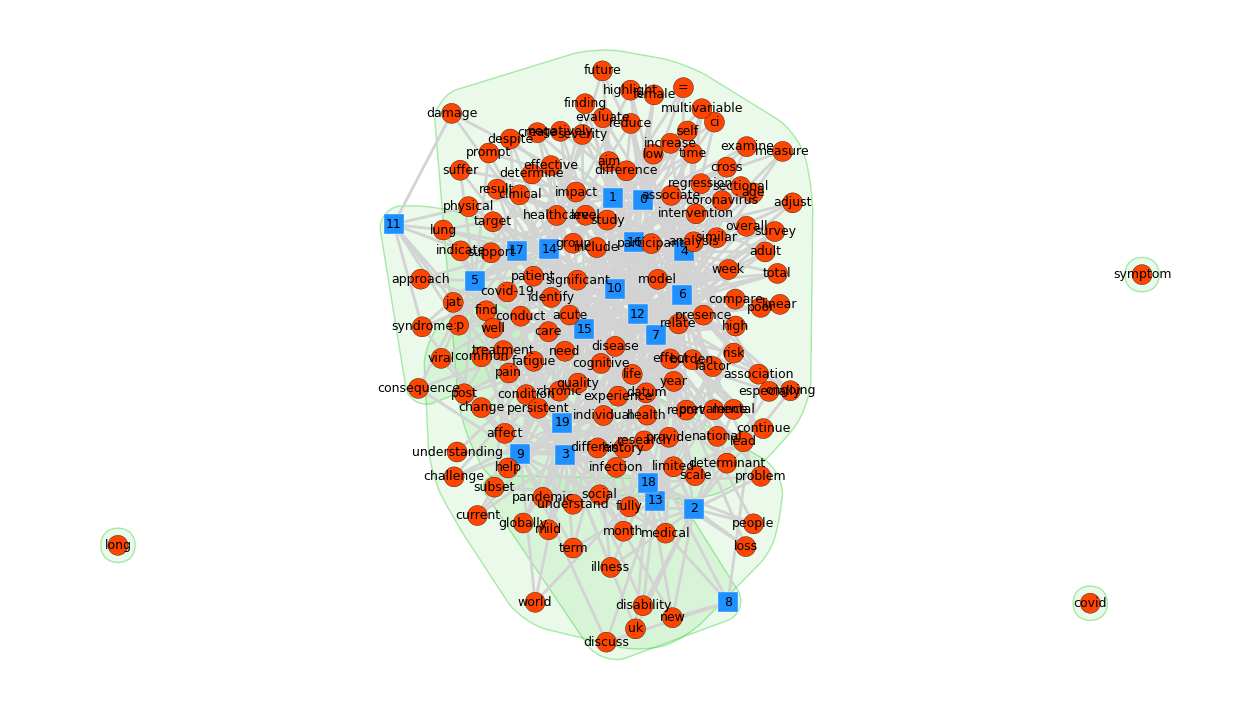

In [16]:
t.plot(label_nodes=True,
       show_clusters=True)

Visualize again but scale the nodes according to their birank and the edges according to their weights

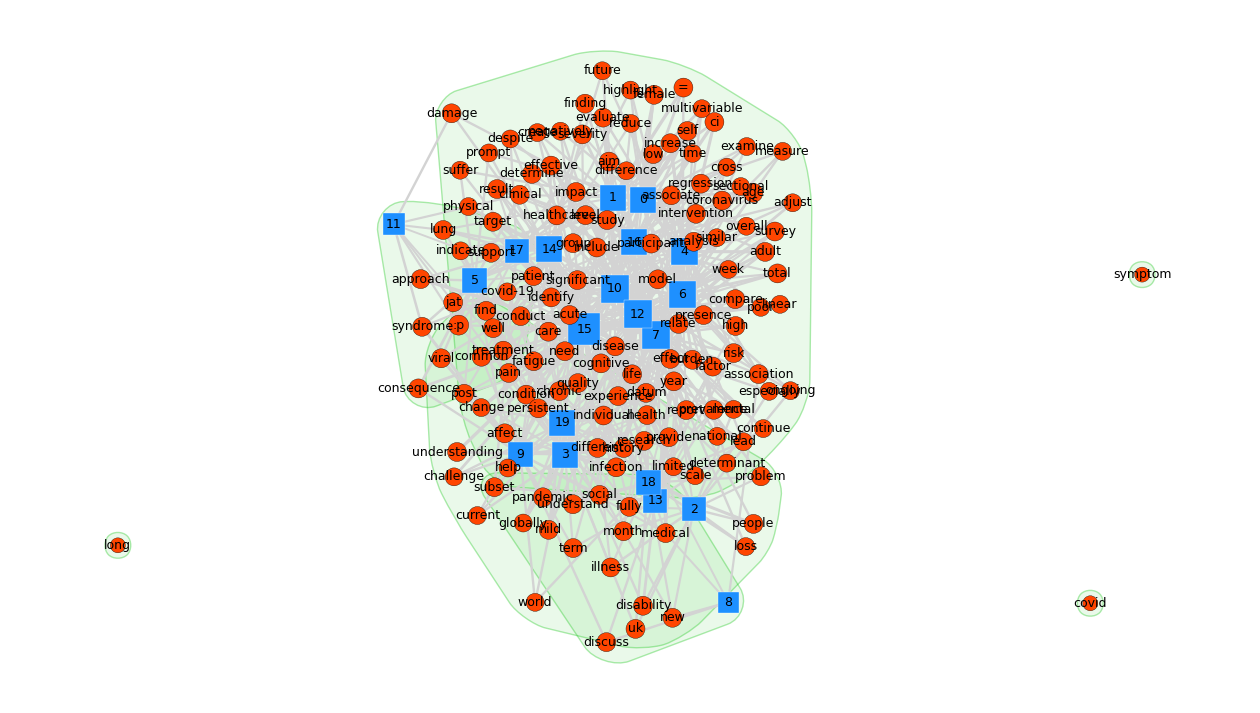

In [17]:
t.plot(label_nodes=True,
       show_clusters=True,
       scale_nodes_by="birank",
       scale_edges_by="weight")

Using the one-node term-to-term projection, clusters can be interpreted as indicating latent themes

In [29]:
terms = t.project(node_type=tn.TERM, connected=True)
terms.top_cluster_nodes()

,nodes,size
cluster,,
0,"[participant, understanding, approach, experie...",59
1,"[associate, adult, ci, age, =, model, total, s...",52
2,"[infection, cognitive, different, individual, ...",30


Visualize projected networks

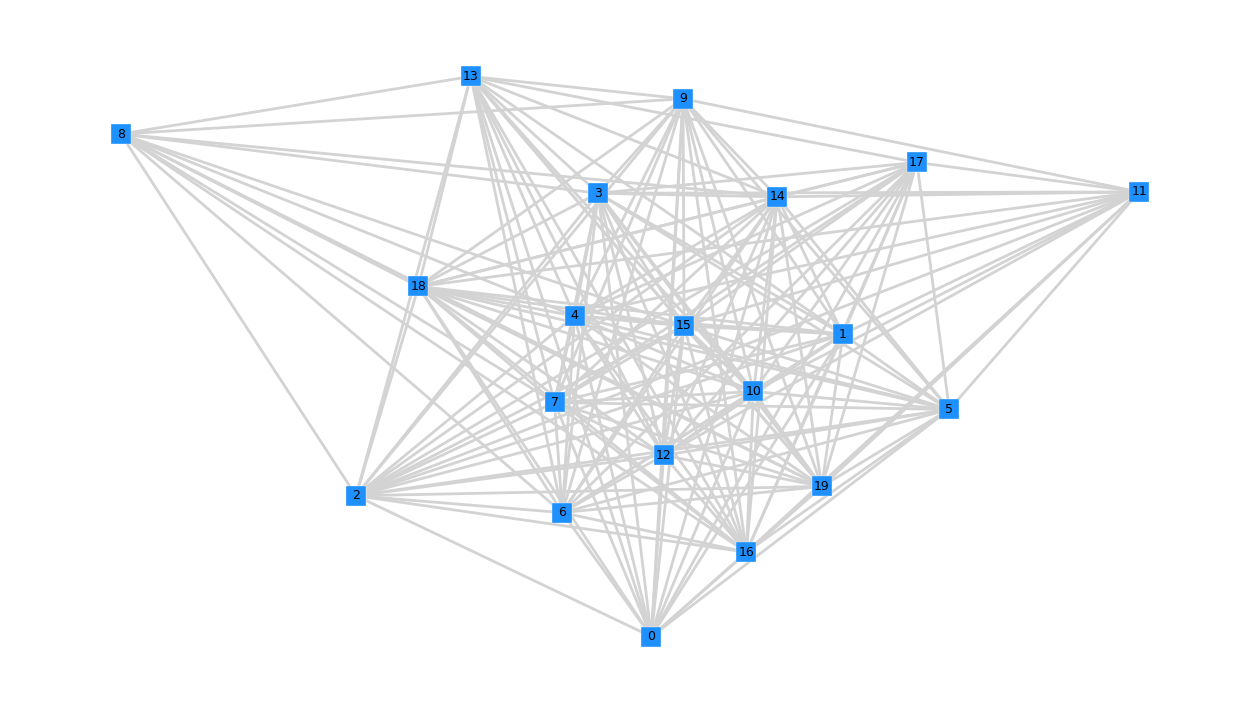

In [19]:
papers = t.project(node_type=tn.DOC)
papers.plot(label_nodes=True)

Visualizing the term network

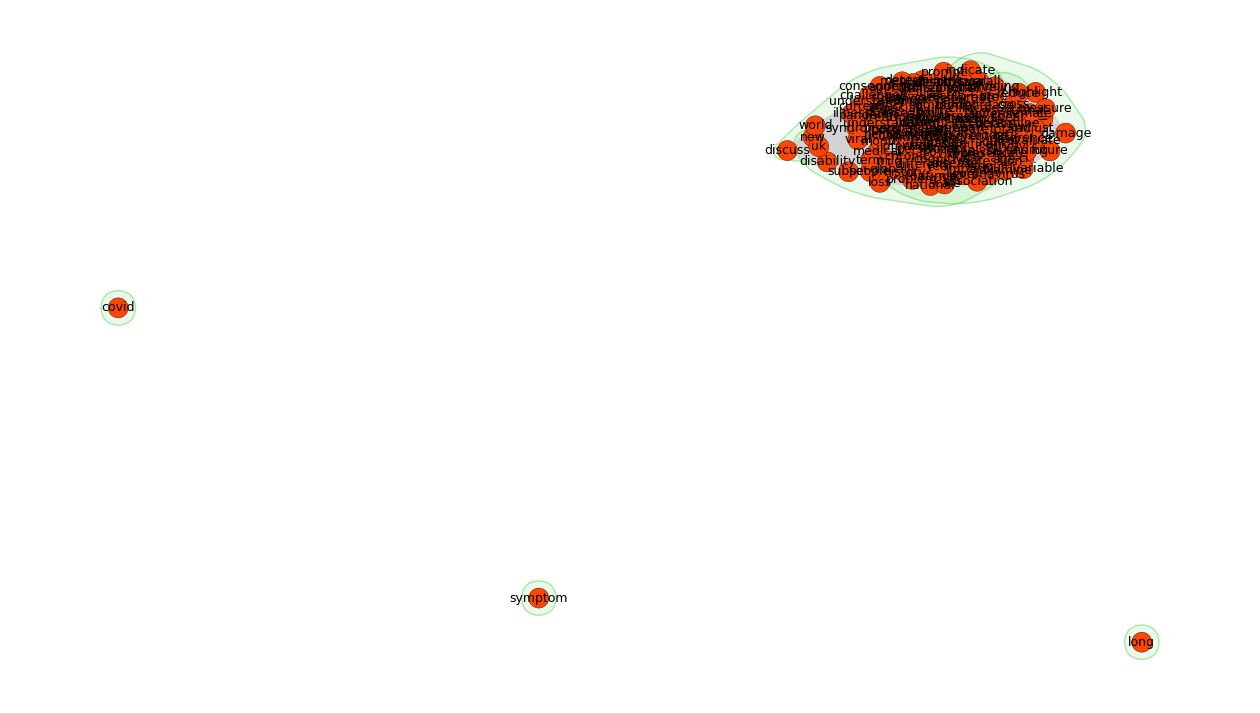

In [20]:
words = t.project(node_type=tn.TERM)
words.plot(label_nodes=True,
           show_clusters=True)

In [21]:
papers.top_betweenness()

,0
15,70.0
9,7.0
4,4.0
0,0.0
3,0.0
2,0.0
1,0.0
6,0.0
7,0.0
8,0.0


In [22]:
words.top_betweenness()

,0
participant,499.0
experience,378.0
associate,236.0
adult,154.0
effect,69.0
self,58.0
find,52.0
group,52.0
well,50.5
ci,49.0


0edges [00:00, ?edges/s]

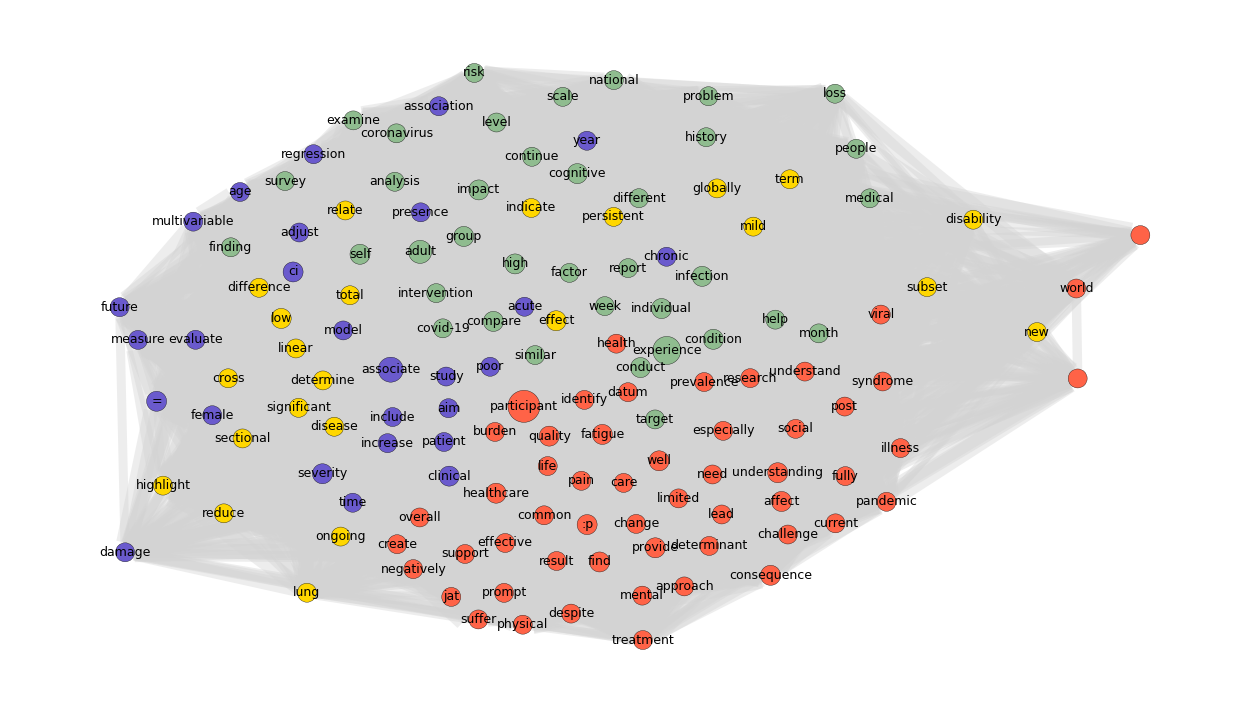

In [23]:
words.plot(label_nodes=True,
           scale_nodes_by="betweenness",
           color_clusters=True,
           alpha=0.5,
           edge_width=[10*w for w in words.edges["weight"]],
           edge_opacity=0.4,
           node_label_filter=lambda n: n.betweenness() > words.betweenness.median())